In [ ]:
import os
import sys
import json
import pathlib
from collections import namedtuple

import pandas as pd
import matplotlib.pyplot as plt

from sktime.performance_metrics.forecasting import (
    MeanAbsolutePercentageError,
    MeanArctangentAbsolutePercentageError,
    MeanSquaredError,
    MeanAbsoluteError
)
from sklearn.metrics import (
    r2_score,
)

In [ ]:
# Add project root to path
sys.path.insert(
    0, 
    os.path.abspath(
        os.path.join(
            os.getcwd(), 
            '..'
        )
    )
)

from src import helper as hl

In [3]:
# Define global variables
CFG_DATA_DIR = pathlib.Path('.')/'data'
CFG_FIGURES_DIR = CFG_DATA_DIR/'fig'
CFG_LOGFILE_DIR = CFG_DATA_DIR/'logs'
CFG_PARQUET_DIR = CFG_DATA_DIR/'parquet'
CFG_PICKLE_DIR = CFG_DATA_DIR/'pickle'

with (
    open(CFG_DATA_DIR / 'txt' / 'client_ids__serveo.txt', 'r') as fp_serveo, 
    open(CFG_DATA_DIR / 'txt' / 'client_ids__divvy.txt', 'r') as fp_divvy, 
    open(CFG_DATA_DIR / 'txt' / 'client_ids__citi.txt', 'r') as fp_citi, 
):
    CFG_CLIENT_IDS = {
        # Identifiers of Serveo dataset
        'serveo': json.load(fp_serveo),
        # Identifiers of Divvy dataset
        'divvy': json.load(fp_divvy),
        # Identifiers of Citi dataset
        'citi': json.load(fp_citi)
    }

# Experiment Parameters

In [4]:
FedGBDP_Experiment = namedtuple(
    'FedGBDP_Experiment',
    [
        'federation',
        'n_estimators',
        'parquet_bs',
        'bs',
        'num_rounds',
        'local_epochs',
        'early_stop',
        'patience',
        'conv_channels',
        'fc_layers',
        'dropout_rate',
        'mu',
        'fraction_fit',
        'fraction_eval',
    ]
)

In [5]:
args = FedGBDP_Experiment(
    federation='citi',
    n_estimators=37,
    bs=64,
    parquet_bs=4096,
    num_rounds=15,
    local_epochs=10,
    early_stop=True,
    patience=5,
    mu=0.125,
    conv_channels=32,
    fc_layers='',
    dropout_rate=0.13,
    fraction_fit=0.25,
    fraction_eval=0.25
)

# Load centralized predictions

In [6]:
if args.federation == 'serveo':
    dataset_params__y_feats = ['target_demand_inbound', 'target_demand_outbound']
else:
    dataset_params__y_feats = ['target_demand_arrivals', 'target_demand_departures']

In [7]:
ebike_results_centralized = pd.concat(
    [
        pd.read_csv(
            CFG_DATA_DIR / 'csv' / args.federation / f'predictions_h6_w168_multi_{feat}.csv',
            parse_dates=['timestamp'],
            dtype={
                'station_id': int if args.federation == 'serveo' else str
            }
        ).rename(
            {
                f'{feat}': f'{feat}__centralized'
            },
            axis=1
        ).set_index(
            [
                'station_id',
                'horizon',
                'timestamp'
            ]
        )

        for feat 
        in dataset_params__y_feats
    ],
    axis=1
)

In [8]:
if args.federation == 'serveo':
    ebike_results_centralized.rename(
        {
            'target_demand_inbound__centralized': 'target_demand_arrivals__centralized',
            'target_demand_outbound__centralized': 'target_demand_departures__centralized'
        },
        axis=1,
        inplace=True
    )

# Load federated predictions

In [10]:
ebike_results_federated = pd.read_pickle(CFG_PICKLE_DIR / f'ebike_results_{args.federation}.pickle.gzip')

In [11]:
ebike_results = ebike_results_federated.join(
    ebike_results_centralized,
    how='left'
)

In [12]:
# Drop NaN records
ebike_results.dropna(inplace=True)

In [13]:
# Round to nearest integer
ebike_results = ebike_results.round()

In [14]:
import tqdm

model_results = {}

for target_feat in ['target_demand_arrivals', 'target_demand_departures']:
    model_results_pred_horizon = {}

    for pred_horizon, pred_horizon_df in tqdm.tqdm(ebike_results.groupby(level=0)):
        model_results_pred_horizon[
                pred_horizon
        ] = hl.evaluate_predictions(
            pred_horizon_df.reset_index(
                level=0, drop=True
            ),
            y_true_name=target_feat,
            y_pred_names=[f'{target_feat}__centralized', f'{target_feat}__local_xgb', f'{target_feat}__global_fedxgb',],
            eval_funs=[
                ('SMAPE_pct', MeanAbsolutePercentageError(symmetric=True), {}),
                ('MAAPE_rads', MeanArctangentAbsolutePercentageError(), {}),
                ('MAE_bikes', MeanAbsoluteError(), {}),
                ('RMSE_bikes', MeanSquaredError(square_root=True), {}),
                ('R2', r2_score, {}),
            ]
        )

    model_results[target_feat] = pd.concat(
        model_results_pred_horizon, names=['client_id']
    )


model_results = pd.concat(
      model_results, names=['output']
)

100%|██████████| 1450/1450 [07:25<00:00,  3.26it/s]


# Visual Inspection

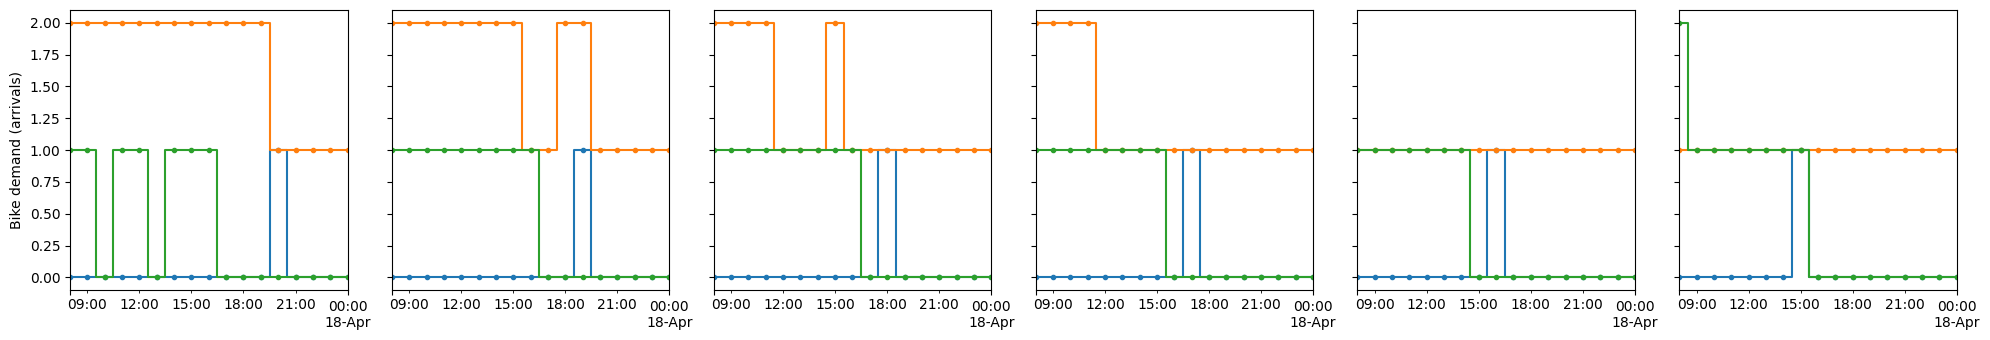

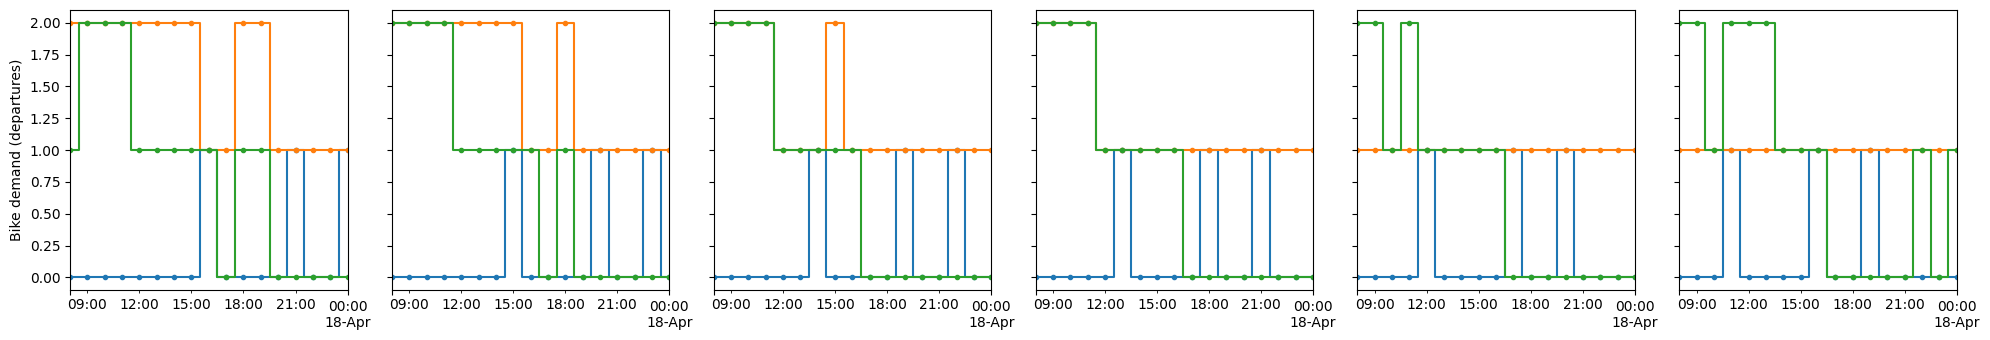

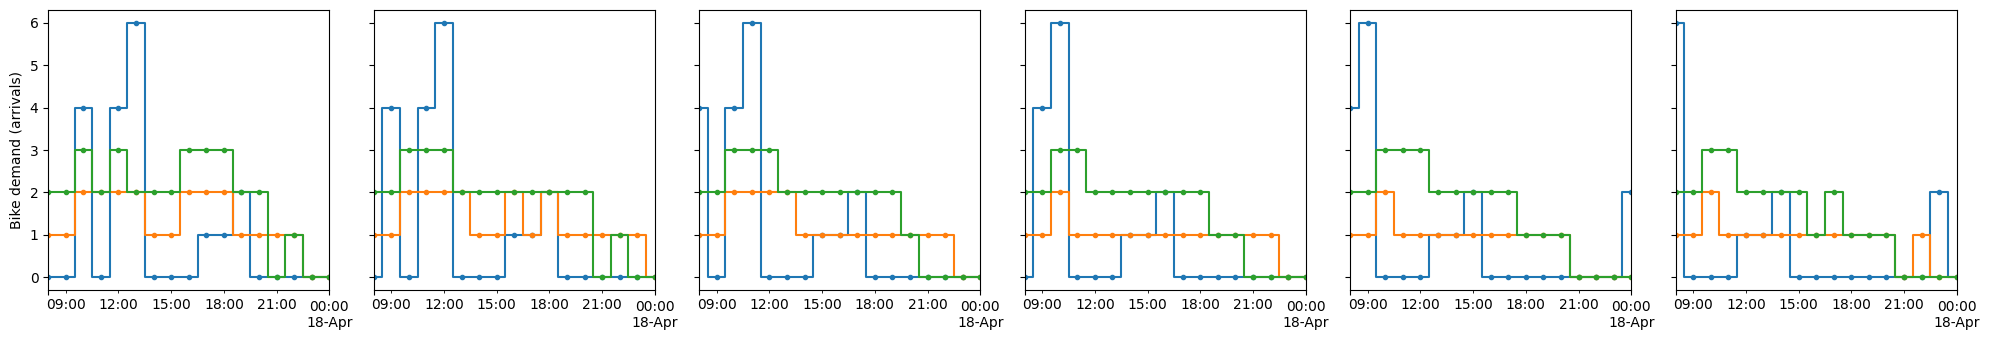

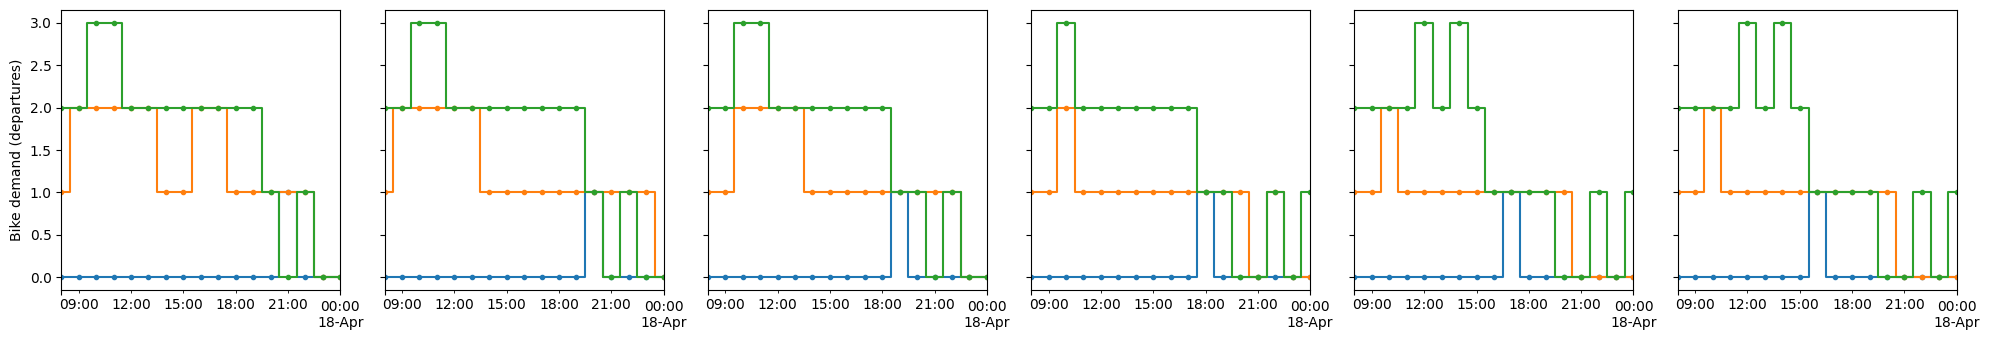

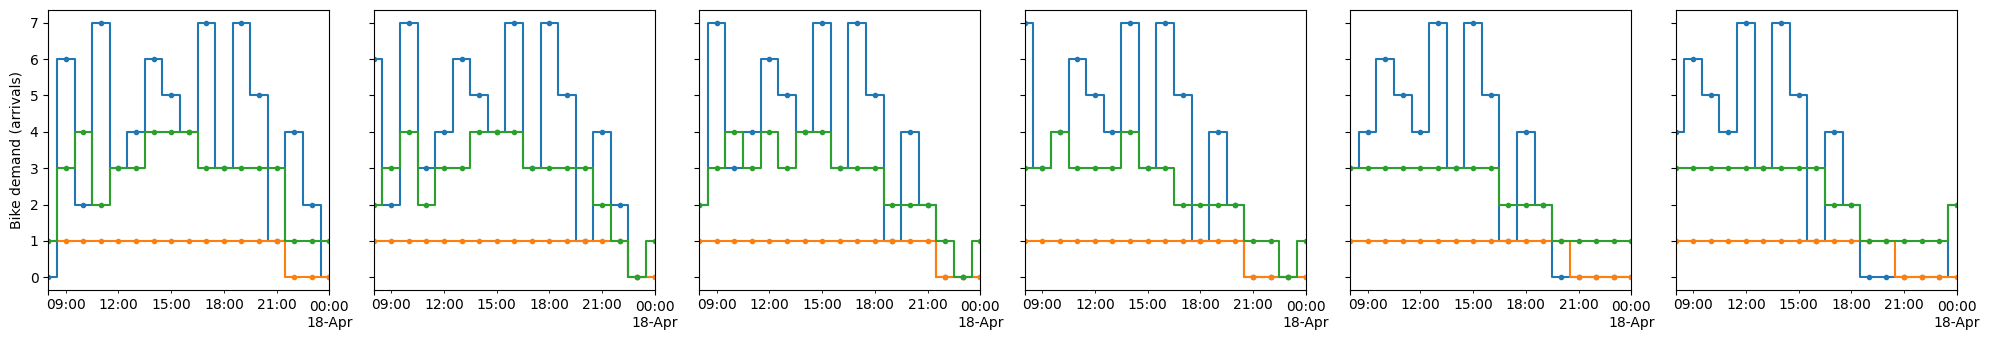

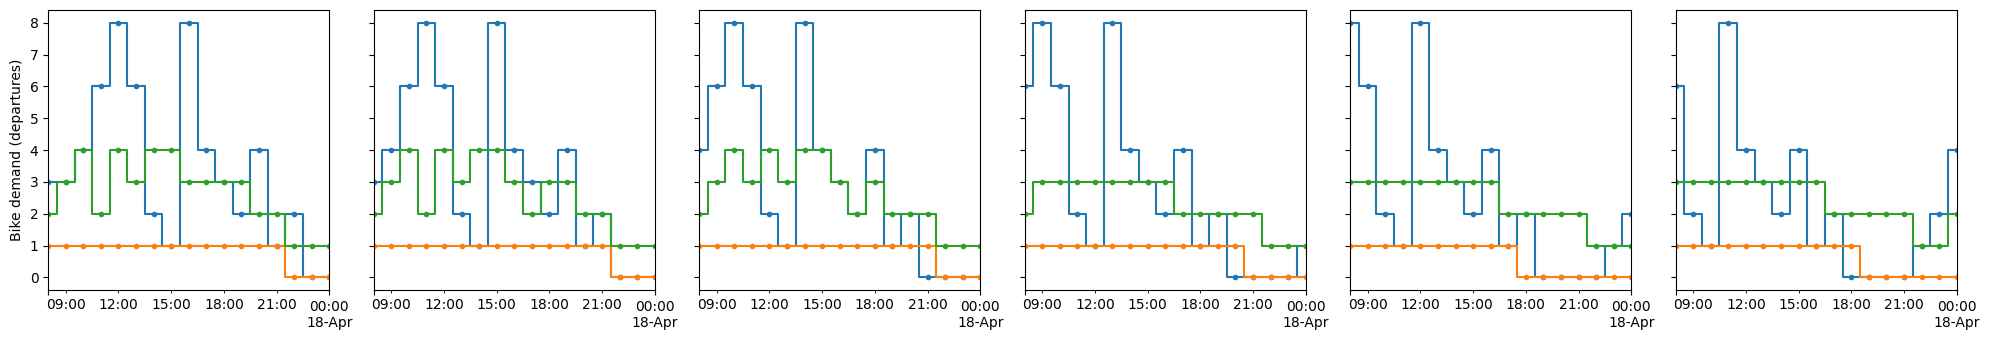

In [74]:
for oid in ['6650.08', '4205.06', '7795.09']:   # Citi
    ix_slice = pd.IndexSlice[
        [oid],
        :,
        '2022-04-17 00:00:00':'2022-04-18 00:00:00'
    ]

    tmp_arr = ebike_results.loc[
        ix_slice,
        [col for col in ebike_results.columns if ('arrivals' in col and 'local' not in col)]
    ].rename(
        {
            'target_demand_arrivals': 'Arrivals (actual)',
            'target_demand_arrivals__global_fedxgb': 'Arrivals (HFL-global)',
            'target_demand_arrivals__centralized': 'Arrivals (CML)'
        },
        axis=1
    ).sort_index()

    tmp_dep = ebike_results.loc[
        ix_slice,
        [col for col in ebike_results.columns if ('departures' in col and 'local' not in col)]
    ].rename(
        {
            'target_demand_departures': 'Departures (actual)',
            'target_demand_departures__global_fedxgb': 'Departures (HFL-global)',
            'target_demand_departures__centralized': 'Departures (CML)'
        },
        axis=1
    ).sort_index()


    for tag, tmp in zip(['arrivals', 'departures'], [tmp_arr, tmp_dep]):
        fig, ax = plt.subplots(1, 6, figsize=(20, 3.5), sharey=True)

        for (_, oid_df), ax_i in zip(
            tmp.groupby(level=(0, 1)),
            ax.flatten()
        ):
            oid_df_flat = oid_df.reset_index(level=(0,1), drop=True)
            
            oid_df_flat.plot(rot=0, drawstyle='steps-mid', ax=ax_i, marker='.', legend=False)
            ax_i.set_ylabel(f'Bike demand ({tag})')

            ax_i.set_xlabel(None)

        plt.tight_layout()
        plt.savefig(f'{args.federation}-ebikes-{oid}-{tag}.pdf', dpi=300)

# Tabular summary

In [82]:
model_results_tab = model_results.groupby(level=3).apply(
    lambda l: l.loc[
        pd.IndexSlice[:, :, :]
    ].groupby(level=2).describe().loc[:, pd.IndexSlice[:, ['mean', 'std']]]
).unstack(
    level=0
).stack(
    level=0, 
    future_stack=True
).reorder_levels(
    (
        1, 0
    )
).sort_index()

In [ ]:
model_results_tab.to_pickle(CFG_PICKLE_DIR / f'fedgbdp_{args.federation}_metrics.pickle.gzip')